Entire process : 
1. importing the dataset
2. Data cleaning and analysis
3. Handling the missing values and duplicates
4. Data visualization
5. Feature encoding (Label encoding and one hot encoding)
6. Splitting the dataset into features and target variable.
7. training the model using 
8. Evaluating the model using the r2_score and mean_absolute_error metirics.
9. User input for Predicting the price of the car.


Importing all the necessary libraries for data manipulation, 
visualiztion, and machine learning.

pandas: for data manipulation and analysis.
numpy : for numerical operations.
matplotlib : for data visualization.
seaborn : for statistical data visualization.

metrics : for evaluating the performance of the models.
train_test_split : for splitting the dataset into training and testing sets.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

Data Collection and Preprocessing

1. Loading the dataset into pandas DataFrame and displayinf the first few rows.
2. Checking the missing values and handling them if necessary.
3. Checking the data types of the columns and converting them if necessary.
4. Checking for duplicates and removing them if necessary.
5. Checking the number of rows and columns in the dataset before splitting it into training and testing sets.


In [19]:
car_dataset = pd.read_csv('Cars_Datasets_2025.csv', encoding='latin1')
car_dataset.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [20]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB


In [21]:
# checking the number of missing values and handling them if necessary.
car_dataset.isnull().sum()

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64

In [22]:
# Handling the missing values by replacing them with the mean value of the respective column.

# separating the numerical and categorical columns for further processing.
num_cols = car_dataset.select_dtypes(include=['number']).columns
cat_cols = car_dataset.select_dtypes(exclude=['number']).columns

# filling the numerical columns with the mean value of the respective column.
car_dataset[num_cols] = car_dataset[num_cols].fillna(car_dataset[num_cols].mean())

# Dropping the missing values in the categorical columns.
car_dataset = car_dataset.dropna(subset=cat_cols)

In [23]:
car_dataset.isnull().sum()

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          0
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    0
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       0
dtype: int64

In [24]:
# Checking for duplicates and removing them if necessary.
car_dataset.duplicated().sum()
car_dataset = car_dataset.drop_duplicates()

In [25]:
# printng the number of rows and columns in the dataser after handling the missing values and duplicates.

print("The number of columns : ", car_dataset.shape[1])
print("The number of rows :", car_dataset.shape[0])



The number of columns :  11
The number of rows : 1206


Data cleaning and analysis

In [26]:
car_dataset['Company Names'] = car_dataset['Company Names'].str.strip().str.title()


# cleaning the 'Fuel Types' column by converting all the values to lowercase and
# replacing the variations of 'petrol/diesel' and 'hybrid' with standarized values 'petrol/diesel' 
# and 'hybrid' respectively.
car_dataset['Fuel Types'] = car_dataset['Fuel Types'].str.lower().str.strip()
car_dataset['Fuel Types'] = car_dataset['Fuel Types'].replace({
    'petrol, diesel': 'petrol/diesel',
    'diesel/petrol': 'petrol/diesel',
    'petrol, hybrid': 'hybrid',
    'hybrid (petrol)': 'hybrid',
    'plug in hyrbrid': 'plug-in hybrid',
    'hybrid (gas + electric)': 'hybrid',
})

# cleaning the 'Engines' column by converting all the values to uppercase and 
# replacing the variations of 'inline-4' with standarized value 'I4'
car_dataset['Engines'] = car_dataset['Engines'].str.upper().str.strip()
car_dataset['Engines'] = car_dataset['Engines'].replace({
    'INLINE-4': 'I4',
    'INLINE 4': 'I4'
})

def simplify_engine(x):
    if 'V8' in x:
        return 'V8'
    elif 'V6' in x:
        return 'V6'
    elif 'V12' in x:
        return 'V12'
    elif 'I4' in x:
        return 'I4'
    else:
        return 'Other'

car_dataset['Engines'] = car_dataset['Engines'].apply(simplify_engine)

# convert text-based numeric fields into usable numbers.
def extract_numeric_value(value):
    if pd.isna(value):
        return np.nan
    numbers = re.findall(r'\d+\.?\d*', str(value).replace(',', ''))
    if not numbers:
        return np.nan
    numbers = [float(num) for num in numbers]
    return sum(numbers) / len(numbers)

car_dataset['Torque'] = car_dataset['Torque'].apply(extract_numeric_value)
car_dataset['Cars Prices'] = car_dataset['Cars Prices'].apply(extract_numeric_value)
car_dataset.head()



,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,Ferrari,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,1100000.0,plug-in hybrid,2,800.0
1,Rolls Royce,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,460000.0,petrol,5,900.0
2,Ford,KA+,Other,"1,200 cc",70-85 hp,165 km/h,10.5 sec,13500.0,petrol,5,120.0
3,Mercedes,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,161000.0,petrol,4,900.0
4,Audi,AUDI R8 Gt,Other,"5,204 cc",602 hp,320 km/h,3.6 sec,253290.0,petrol,2,560.0


In [27]:
car_dataset['CC/Battery Capacity'] = car_dataset['CC/Battery Capacity'].apply(extract_numeric_value)
car_dataset['Total Speed'] = car_dataset['Total Speed'].apply(extract_numeric_value)
car_dataset['HorsePower'] = car_dataset['HorsePower'].apply(extract_numeric_value)
car_dataset['Performance(0 - 100 )KM/H'] = car_dataset['Performance(0 - 100 )KM/H'].apply(extract_numeric_value)
car_dataset['Seats'] = car_dataset['Seats'].apply(extract_numeric_value)

# fill any numeric gaps created during extraction before modeling.
numeric_cols = [
    'CC/Battery Capacity', 'HorsePower', 'Total Speed',
    'Performance(0 - 100 )KM/H', 'Seats', 'Torque', 'Cars Prices'
]
car_dataset[numeric_cols] = car_dataset[numeric_cols].apply(lambda col: col.fillna(col.median()))

car_dataset['Cars Prices'] = np.log1p(car_dataset['Cars Prices'])
car_dataset = car_dataset.drop(columns=['Cars Names'])

q_low = car_dataset['Cars Prices'].quantile(0.01)
q_high = car_dataset['Cars Prices'].quantile(0.99)

car_dataset = car_dataset[(car_dataset['Cars Prices'] > q_low) & (car_dataset['Cars Prices'] < q_high)]
car_dataset[numeric_cols].isnull().sum()

CC/Battery Capacity          0
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    0
Seats                        0
Torque                       0
Cars Prices                  0
dtype: int64

Lets analyze the dataset: 
1. knowing the types of companies and the number of cars from each company.
2. Types of engines used.
3. Types of fuel used.




Top Companies:
 Company Names
Nissan               158
Volkswagen           107
Porsche               96
Mazda                 83
Kia                   71
Gmc                   59
Chevrolet             57
Mitsubishi            56
Ford                  54
Peugeot               54
Toyota                49
Bmw                   41
Jaguar Land Rover     40
Rolls Royce           30
Acura                 27
Lamborghini           23
Hyundai               23
Audi                  21
Mercedes              20
Cadillac              20
Jeep                  19
Tata Motors           17
Volvo                 12
Tesla                 10
Aston Martin          10
Ferrari                9
Honda                  7
Maruti Suzuki          3
Mahindra               3
Bentley                1
Name: count, dtype: int64


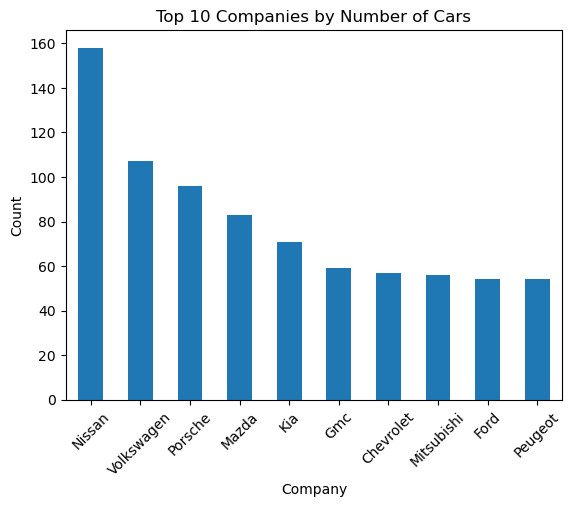


Top Engine Types:
 Engines
Other    537
I4       233
V6       205
V8       156
V12       49
Name: count, dtype: int64


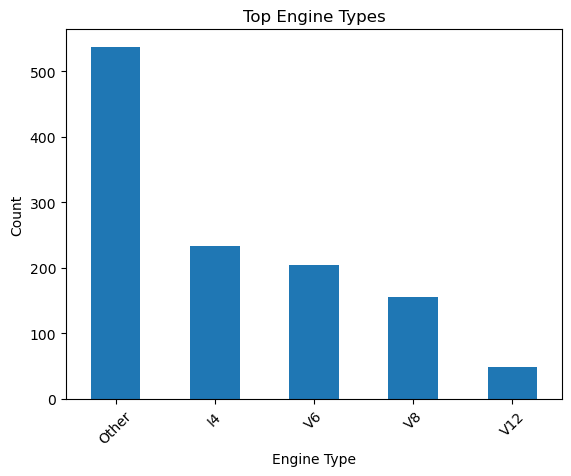


Fuel Types:
 Fuel Types
petrol              850
diesel               99
electric             94
hybrid               84
petrol/diesel        20
petrol/hybrid        16
plug-in hybrid        6
hydrogen              3
petrol/awd            2
petrol/ev             1
hybrid/electric       1
cng/petrol            1
hybrid/petrol         1
gas / hybrid          1
hybrid / plug-in      1
Name: count, dtype: int64


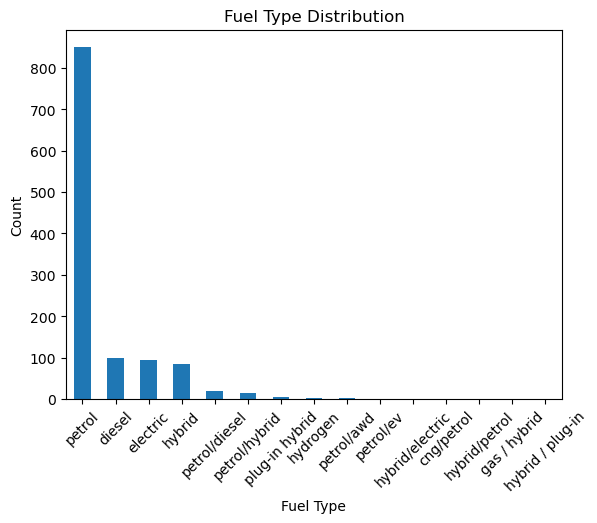

In [33]:
# Lets analyze the dataset:

# 1️⃣ Company Analysis
company_counts = car_dataset['Company Names'].value_counts()
print("\nTop Companies:\n", company_counts)
# Bar Graph
plt.figure()
company_counts.head(10).plot(kind='bar')
plt.title("Top 10 Companies by Number of Cars")
plt.xlabel("Company")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# 2️⃣ Engine Types Analysis
engine_counts = car_dataset['Engines'].value_counts()
print("\nTop Engine Types:\n", engine_counts.head(10))
# Bar Graph
plt.figure()
engine_counts.head(10).plot(kind='bar')
plt.title("Top Engine Types")
plt.xlabel("Engine Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 3️⃣ Fuel Types Analysis
fuel_counts = car_dataset['Fuel Types'].value_counts()
print("\nFuel Types:\n", fuel_counts)
# Bar Graph
plt.figure()
fuel_counts.plot(kind='bar')
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()





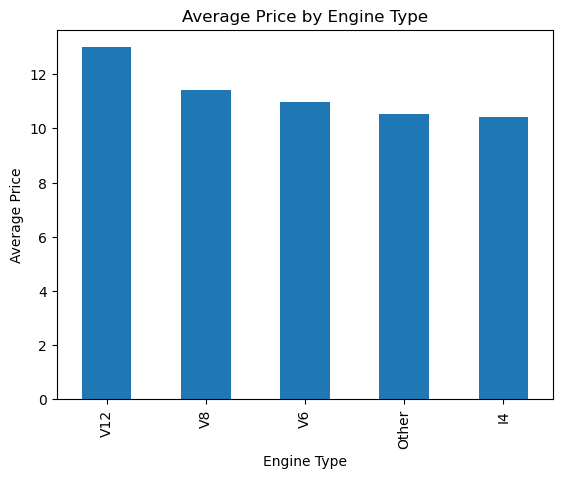

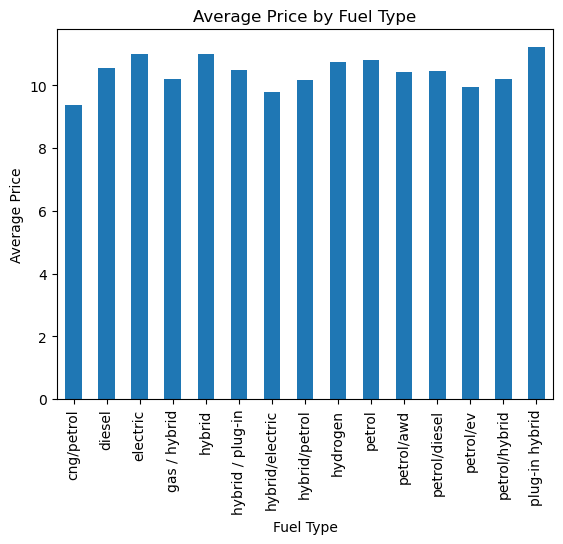

In [32]:
# Engine vs Price Analysis
engine_price = car_dataset.groupby('Engines')['Cars Prices'].mean().sort_values(ascending=False)

engine_price.head(10).plot(kind='bar')
plt.title("Average Price by Engine Type")
plt.xlabel("Engine Type")
plt.ylabel("Average Price")
plt.show()

# Fuel type vs price Analysis
fuel_price = car_dataset.groupby('Fuel Types')['Cars Prices'].mean()

fuel_price.plot(kind='bar')
plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.show()




In [12]:
# label encoding and one hot encoding the categorical data for further processing.
le = LabelEncoder()
# encoding the company names column using label encoding. 
car_dataset['Company Names'] = le.fit_transform(car_dataset['Company Names'])
# encoding the fuel types and simplified engine categories using one hot encoding.
car_dataset = pd.get_dummies(car_dataset, columns=['Fuel Types', 'Engines'], drop_first=True)
car_dataset.head()

,Company Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Fuel Types_diesel,Fuel Types_electric,...,Fuel Types_petrol,Fuel Types_petrol/awd,Fuel Types_petrol/diesel,Fuel Types_petrol/ev,Fuel Types_petrol/hybrid,Fuel Types_plug-in hybrid,Engines_Other,Engines_V12,Engines_V6,Engines_V8
0,7,3990.0,963.0,340.0,2.5,13.910822,2.0,800.0,False,False,...,False,False,False,False,False,True,False,False,False,True
1,24,6749.0,563.0,250.0,5.3,13.038984,5.0,900.0,False,False,...,True,False,False,False,False,False,False,True,False,False
2,8,1200.0,77.5,165.0,10.5,9.510519,5.0,120.0,False,False,...,True,False,False,False,False,False,True,False,False,False
3,19,3982.0,630.0,250.0,3.2,11.989166,4.0,900.0,False,False,...,True,False,False,False,False,False,False,False,False,True
4,2,5204.0,602.0,320.0,3.6,12.442294,2.0,560.0,False,False,...,True,False,False,False,False,False,True,False,False,False


Now lets split the dataset into features and target variable.

In [13]:
# features
x = car_dataset.drop(columns=['Cars Prices'], axis=1)
# target variable
y = car_dataset['Cars Prices']

print("Features shape:", x.shape)
print("Target shape:", y.shape)

print("\nFeature Columns:\n", x.columns)

Features shape: (1180, 25)
Target shape: (1180,)

Feature Columns:
 Index(['Company Names', 'CC/Battery Capacity', 'HorsePower', 'Total Speed',
       'Performance(0 - 100 )KM/H', 'Seats', 'Torque', 'Fuel Types_diesel',
       'Fuel Types_electric', 'Fuel Types_gas / hybrid', 'Fuel Types_hybrid',
       'Fuel Types_hybrid / plug-in', 'Fuel Types_hybrid/electric',
       'Fuel Types_hybrid/petrol', 'Fuel Types_hydrogen', 'Fuel Types_petrol',
       'Fuel Types_petrol/awd', 'Fuel Types_petrol/diesel',
       'Fuel Types_petrol/ev', 'Fuel Types_petrol/hybrid',
       'Fuel Types_plug-in hybrid', 'Engines_Other', 'Engines_V12',
       'Engines_V6', 'Engines_V8'],
      dtype='object')


In [14]:
# now splitting the dataset into training and testing sets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=12)


In [15]:
# Model training using Random Forest Regressor
# get the model
rfr_model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
# fit the model to the training data
rfr_model.fit(x_train, y_train)
# predictions using the trained model on the test data.
y_pred = rfr_model.predict(x_test)


Evaluation of the model using ths R2_SCORE and mean_absolute_error metrics.

In [16]:
# Now using the r2_score and mean_absolute_error metrics to evaluate the model performance.

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

r2 = metrics.r2_score(y_test_actual, y_pred_actual)
mae = metrics.mean_absolute_error(y_test_actual, y_pred_actual)

print("The r2 score of the model is : ", r2)
print("The mean absolute error of the model is : ", mae)


The r2 score of the model is :  0.8450744091403952
The mean absolute error of the model is :  12437.472578876037


Predicting the price of the car using user input.

In [17]:
# Take input
cc = float(input("Enter CC: "))
hp = float(input("Enter HP: "))
speed = float(input("Enter Speed: "))
acc = float(input("Enter 0-100 time: "))
seats = int(input("Enter seats: "))
torque = float(input("Enter torque: "))

# Create dataframe
input_data = pd.DataFrame({
    'CC/Battery Capacity': [cc],
    'HorsePower': [hp],
    'Total Speed': [speed],
    'Performance(0 - 100 )KM/H': [acc],
    'Seats': [seats],
    'Torque': [torque]
})

# Match columns
input_data = input_data.reindex(columns=x.columns, fill_value=0)

# Predict
prediction = rfr_model.predict(input_data)

# Reverse log (if applied)
import numpy as np
final_price = np.expm1(prediction[0])

print("Predicted Car Price:", final_price)

Predicted Car Price: 14211.787095892907
